# Pandas Part 2: Income Groups and Carbon Efficiency

This notebook rebuilds the core panel, assigns income groups, and focuses on distributional comparisons, carbon intensity, z-score outliers, and the recent improver analysis.

Links:
- [Pandas index](../data_analytics_project_pandas.ipynb)
- [Shared helpers](../functions.py)

In [1]:
%load_ext autoreload
%autoreload 2
# TODO: Update it to the same level as the polars notebook

In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'co2_data.csv').exists() and (candidate / 'notebooks' / 'functions.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
DATA_DIR = REPO_ROOT / 'data'

In [3]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import umap.umap_ as umap

import timeit
import requests
import json
from flatten_json import flatten

from functions import (
    apply_correlation_to_df,
    normalize_column,
    z_score_column,
    safe_divide,
    classify_income_group,
    get_top_bottom_n,
    compute_energy_mix_shares,
    plot_dual_axis_timeseries,
    run_kmeans_elbow,
    fetch_wikipedia_gni_table,
)

# professional theme: clean white grid with muted palette
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
%matplotlib inline


/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [4]:
co2_df = pd.read_csv(DATA_DIR / 'co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
co2_df = co2_df[co2_df['iso_code'].notna() & (co2_df['iso_code'].str.strip() != '')]
co2_df = co2_df[co2_df['year'] > 1960]

co2_df


,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pd.melt()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [5]:
# load GDP data
gdp_df = pd.read_csv(DATA_DIR / 'gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_df['year'] = gdp_df['year'].astype(int)
gdp_df['gdp'] = pd.to_numeric(gdp_df['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_df = gdp_df.dropna(subset=['gdp'])

gdp_df

,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.

### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

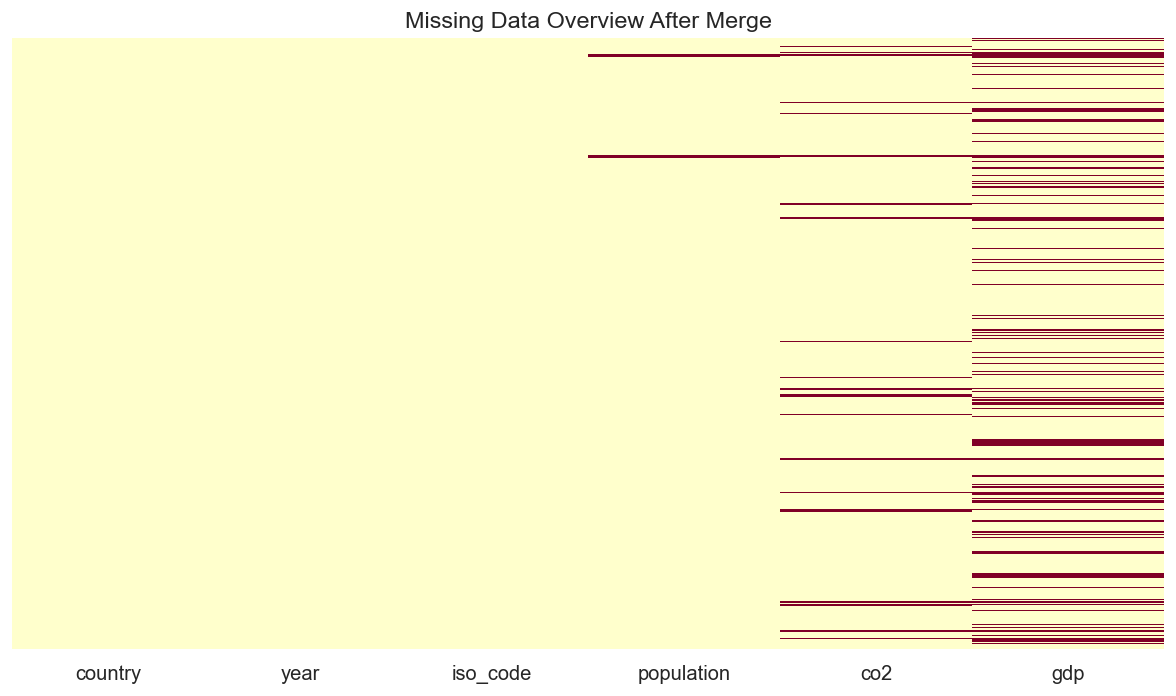

In [6]:
# merge the datasets on iso_code and year
base_df = co2_df.merge(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# missing data heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(base_df.isnull(), yticklabels=False, cbar=False, cmap='YlOrRd', ax=ax)
ax.set_title("Missing Data Overview After Merge")
plt.tight_layout()
plt.show()


### Data Quality Summary

The GDP column shows the most missingness - this is expected since many countries (especially newly independent or conflict-affected states) lack World Bank GDP records in earlier decades. Importantly, the missingness is **systematic** rather than random: it concentrates in specific countries and time periods. This means any analysis involving GDP will implicitly exclude these observations, so conclusions are most robust for the subset of countries with consistent economic data.

## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

- **CO2 per capita** is expressed in **tonnes per person** (the raw CO2 column is in millions of tonnes, so we multiply by 10⁶ before dividing by population).
- **GDP per capita** is in **current USD per person**.

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

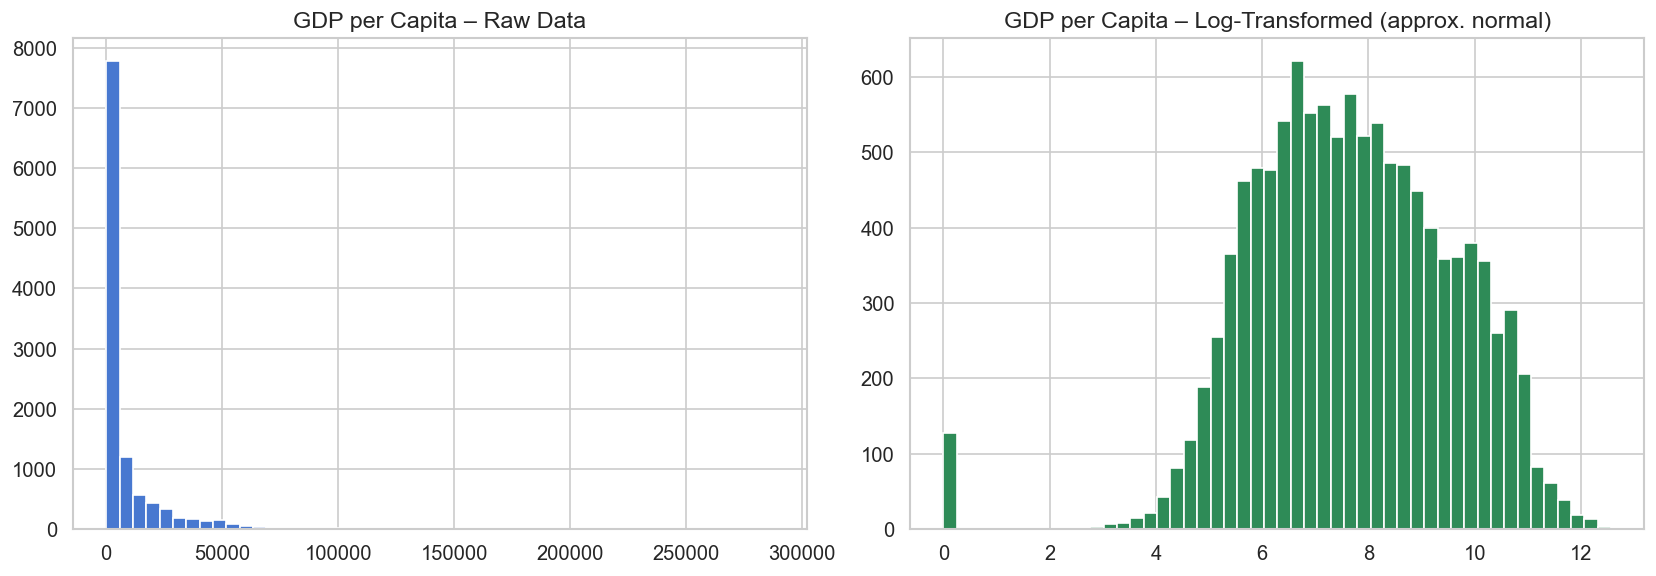

In [7]:
# CO2 is in millions of tonnes; multiply by 1e6 to get tonnes, then divide by population
base_df['co2_per_capita'] = safe_divide(base_df['co2'].values * 1e6, base_df['population'].values)
base_df['gdp_per_capita'] = safe_divide(base_df['gdp'].values, base_df['population'].values)

# Log-transform per-capita metrics for better visualization
base_df['log_gdp_pc'] = np.log1p(base_df['gdp_per_capita'].values)
base_df['log_co2_pc'] = np.log1p(base_df['co2_per_capita'].values)

# compare raw and log-transformed data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(base_df['gdp_per_capita'].dropna(), bins=50, edgecolor='white')
axes[0].set_title('GDP per Capita – Raw Data')
axes[1].hist(base_df['log_gdp_pc'].dropna(), bins=50, edgecolor='white', color='seagreen')
axes[1].set_title('GDP per Capita – Log-Transformed (approx. normal)')
plt.tight_layout()
plt.show()


# Correlation Analysis

To quantify the relationship between economic growth and carbon emissions, we compute the **Pearson correlation coefficient** (r) between GDP per capita and CO2 per capita for each country across its full available time series.

- **r close to +1** indicates strong coupling - GDP and emissions rise together, typical of industrializing economies reliant on fossil fuels.
- **r close to 0** suggests no linear relationship - the two metrics move independently.
- **r < 0** indicates **decoupling** - GDP continues to grow while emissions decline, often driven by transitions to services-based economies, renewable energy adoption, or efficiency gains.

A minimum of 5 data points per country is required to compute a meaningful correlation; countries with fewer observations are excluded. It is worth noting that Pearson r captures only *linear* association - a country that industrialized heavily, peaked, and then decoupled will show a moderate positive r despite having a clear structural break in its emission trajectory.

In [8]:
base_df['Correlation'] = apply_correlation_to_df(base_df)

# Finland
fin = base_df[base_df['country'] == 'Finland'].dropna(subset=['gdp_per_capita', 'co2_per_capita'])

# fit a linear trend line
slope, intercept = np.polyfit(fin['gdp_per_capita'].values, fin['co2_per_capita'].values, deg=1)
print(f"Trend: CO2_pc = {slope:.6f} × GDP_pc + {intercept:.2f}")

base_df

Trend: CO2_pc = 0.000020 × GDP_pc + 9.06


/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,Correlation
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,0.053288,NaN,NaN,0.051917,0.915700
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,0.073264,NaN,NaN,0.070704,0.915700
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,0.073611,NaN,NaN,0.071028,0.915700
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,0.085487,NaN,NaN,0.082029,0.915700
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,0.100339,NaN,NaN,0.095618,0.915700
...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,-0.507579
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,-0.507579
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,-0.507579
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,-0.507579


## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset, then apply `pd.cut` to assign income brackets based on GDP per capita as a proxy.

In [9]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

# pd.read_html would have been possible too
# but BeautifulSoup gives us more control over the wikipedia table structure
gni_df = fetch_wikipedia_gni_table(url)

gni_df


,,Country,gni_per_capita,Year
0,,Country,1.0,Year
1,,High Income Economies,NaN,2024
2,–,Bermuda (UK),145150.0,2024
3,1,Liechtenstein,116600.0,2009
4,2,Norway,98170.0,2024
...,...,...,...,...
208,187,Madagascar,510.0,2024
209,188,Yemen,470.0,2024
210,189,Afghanistan,370.0,2023
211,190,South Sudan,350.0,2024


In [10]:
# normalize 
gni_df['country_clean'] = normalize_column('Country', gni_df)
base_df['country_clean'] = normalize_column('country', base_df)

# left merge
main_df = pd.merge(base_df, gni_df[['country_clean', 'gni_per_capita']], 
                     on='country_clean', how='left')

# classify income groups using World Bank thresholds
main_df['income_group'] = classify_income_group(main_df['gni_per_capita'])

main_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,Correlation,country_clean,gni_per_capita,income_group
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,0.053288,NaN,NaN,0.051917,0.915700,afghanistan,370.0,Low
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,0.073264,NaN,NaN,0.070704,0.915700,afghanistan,370.0,Low
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,0.073611,NaN,NaN,0.071028,0.915700,afghanistan,370.0,Low
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,0.085487,NaN,NaN,0.082029,0.915700,afghanistan,370.0,Low
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,0.100339,NaN,NaN,0.095618,0.915700,afghanistan,370.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,-0.507579,zimbabwe,2260.0,Lower-Middle
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,-0.507579,zimbabwe,2260.0,Lower-Middle
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,-0.507579,zimbabwe,2260.0,Lower-Middle
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,-0.507579,zimbabwe,2260.0,Lower-Middle


### Distribution of Income Groups (2024)

Before comparing emissions across income groups, we first check how many countries fall into each bracket in 2024. This serves as a **sanity check** - if one group is heavily overrepresented or nearly empty, later comparisons would be unreliable due to uneven sample sizes. The countplot also reflects the current structure of global economic inequality.

/var/folders/61/7lw43jz92wn9qxlh9cdtg5z80000gn/T/ipykernel_34728/3703164616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_2024, x='income_group', order=income_order, palette='viridis', ax=ax)


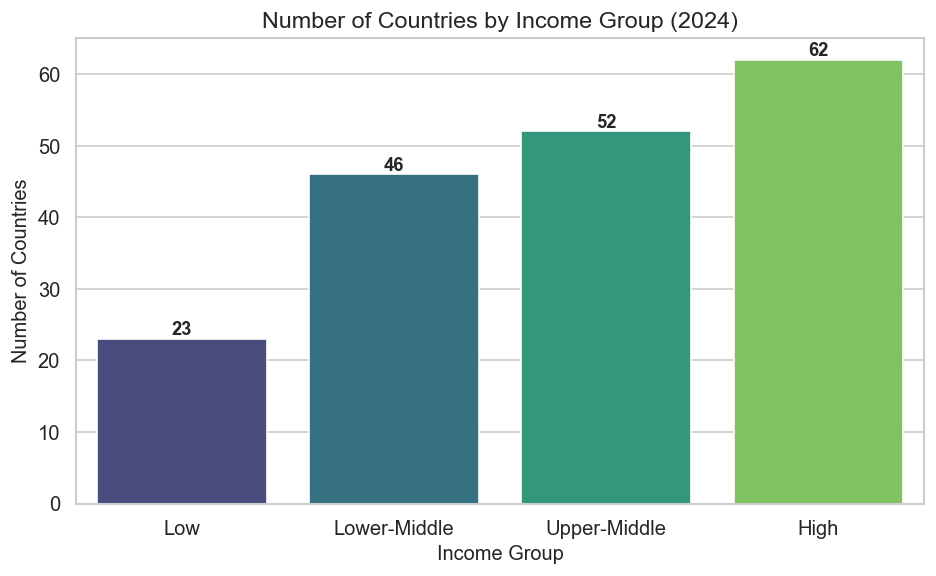

In [11]:
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
df_2024 = main_df[main_df['year'] == 2024].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_2024, x='income_group', order=income_order, palette='viridis', ax=ax)
ax.set_title('Number of Countries by Income Group (2024)')
ax.set_xlabel('Income Group')
ax.set_ylabel('Number of Countries')

# annotate bar counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/61/7lw43jz92wn9qxlh9cdtg5z80000gn/T/ipykernel_34728/3170184677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax1, x='income_group', y='Correlation', data=df_2024,
/var/folders/61/7lw43jz92wn9qxlh9cdtg5z80000gn/T/ipykernel_34728/3170184677.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers,


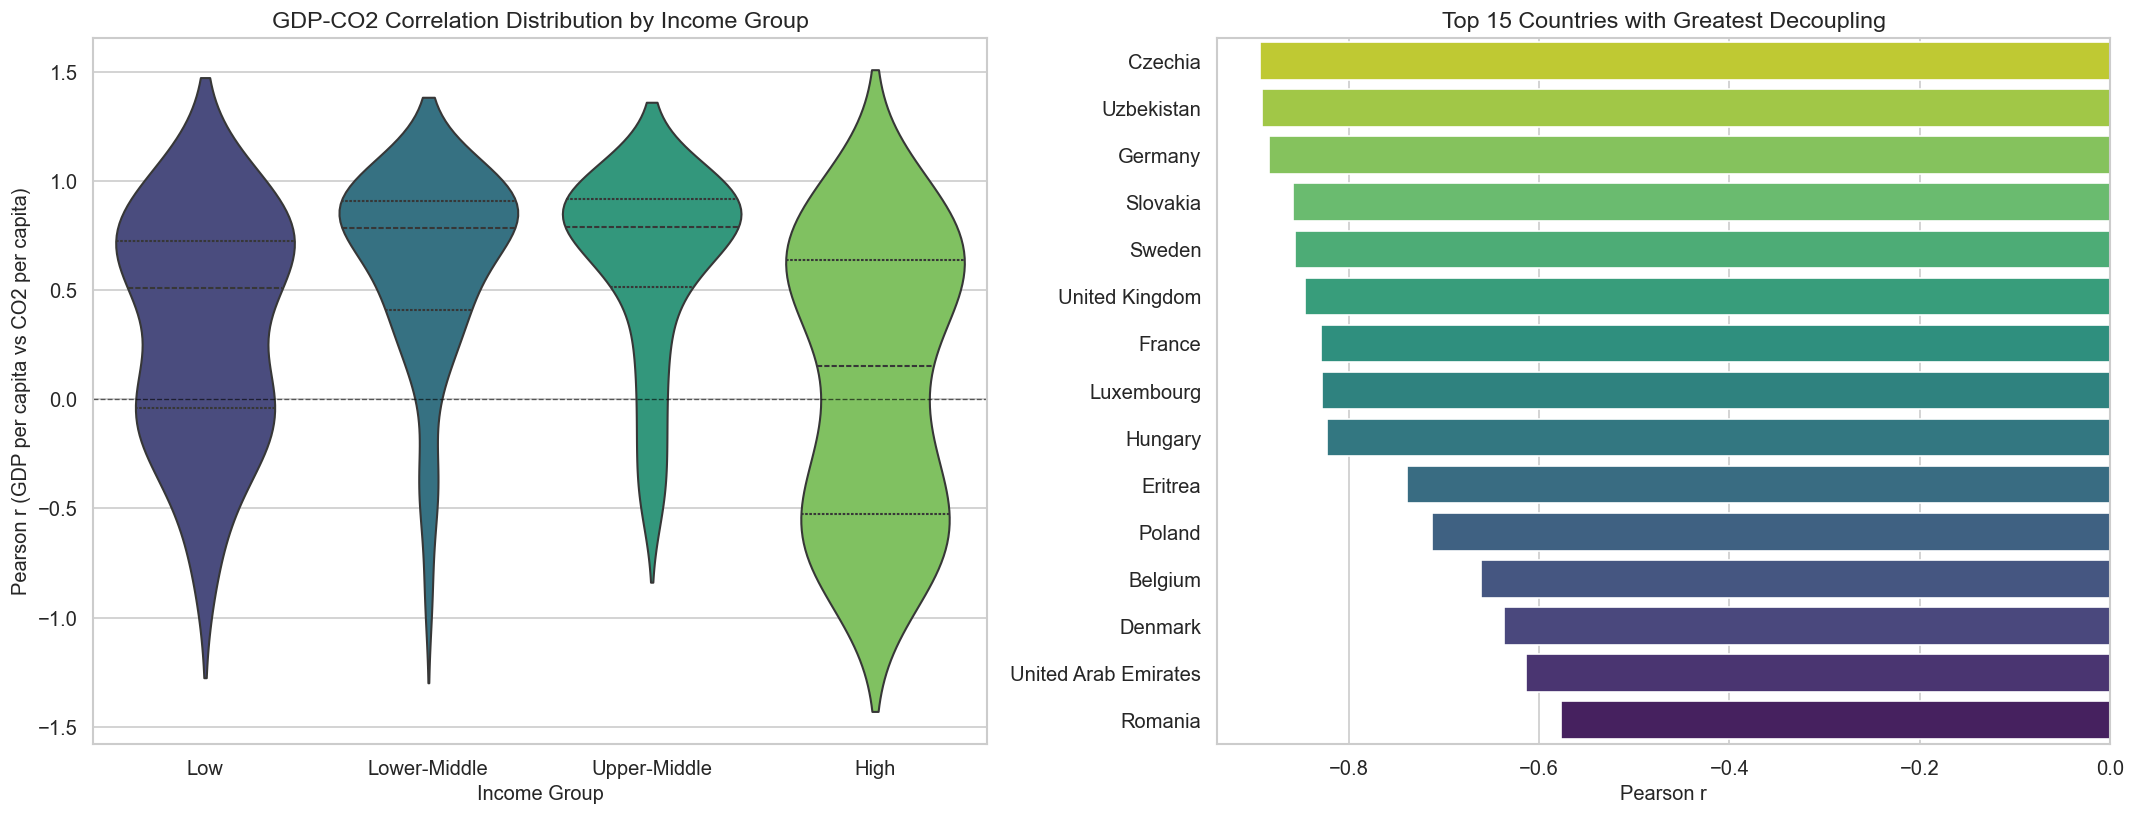

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# violin plot: correlation distribution by income group
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
sns.violinplot(ax=ax1, x='income_group', y='Correlation', data=df_2024,
               order=income_order, palette='viridis', inner='quartile')
ax1.set_title('GDP-CO2 Correlation Distribution by Income Group')
ax1.set_xlabel('Income Group')
ax1.set_ylabel('Pearson r (GDP per capita vs CO2 per capita)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# bar chart: top 15 decouplers (most negative correlation)
top_decouplers = get_top_bottom_n(df_2024, 'Correlation', n=15)
sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers,
            palette='viridis_r')
ax2.set_title('Top 15 Countries with Greatest Decoupling')
ax2.set_xlabel('Pearson r')
ax2.set_ylabel('')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpreting the Results

The violin plot reveals how the GDP–CO2 correlation distributes within each income bracket. High-income countries show a wider spread with more negative correlations, suggesting that decoupling is more prevalent - and more varied - among wealthy nations. Lower-income groups cluster tightly around positive correlations, indicating that economic growth and emissions still move in tandem.

The bar chart of the top 15 decouplers (most negative Pearson r) surfaces some initially surprising entries - Uzbekistan and Czechia rank highly. However, this is consistent with the post-Soviet economic transition: many former Eastern Bloc countries experienced simultaneous GDP growth and emissions decline as they dismantled inefficient heavy industry inherited from the Soviet era and transitioned toward market economies with lighter industrial footprints.

The presence of the UAE among the top decouplers likely reflects its aggressive economic diversification away from oil dependency toward tourism, finance, and technology - sectors that generate GDP without proportional CO2 increases.

### Historical Emission Paths by Income Group

The FacetGrid below plots per-capita CO2 over time, split into separate panels by income group. Each panel uses `sns.lineplot`, which computes the **mean** across all countries in that bracket along with a 95% confidence interval (shaded band).

We use separate panels rather than overlaying all four groups on a single axis for two reasons:
1. High-income countries emit orders of magnitude more per capita than low-income ones, which would compress the lower groups into flat lines at the bottom of a shared y-axis.
2. `sharey=False` gives each panel its own y-scale, allowing the internal trends within each group to be clearly visible.

**Key patterns to look for:**
- **High income**: A rise-then-decline trajectory - emissions peaked around the 1970s–2000s and have since been falling, consistent with deindustrialization, fuel switching, and policy intervention.
- **Upper-Middle**: Rapid growth phase, potentially still climbing as industrialization continues (driven heavily by China's trajectory in this bracket).
- **Lower-Middle / Low**: Flat, low emissions - these countries have contributed minimally to cumulative global CO2 despite housing large shares of the world's population.

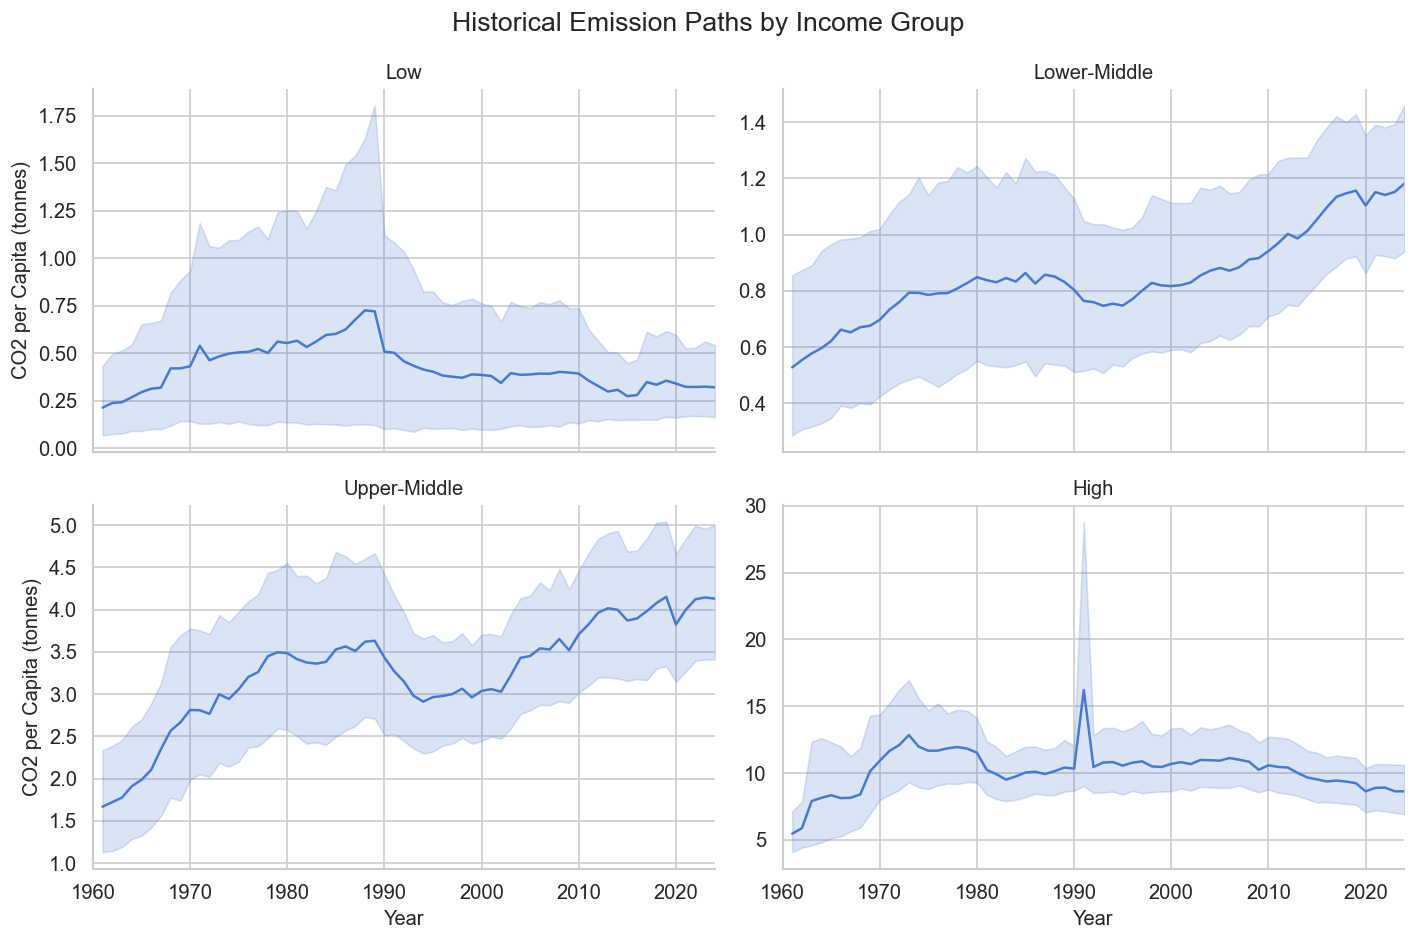

In [13]:
# compare historical emissions paths by income group
g = sns.FacetGrid(main_df, col="income_group", col_wrap=2, height=4, aspect=1.5,
                  sharey=False, col_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
g.map(sns.lineplot, "year", "co2_per_capita")

g.set(xlim=(1960, 2024))
g.set_axis_labels("Year", "CO2 per Capita (tonnes)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Historical Emission Paths by Income Group", fontsize=16)
plt.show()

### Observations

The faceted emission trajectories confirm a clear structural divide:

- **High-income countries** show the classic inverted-U pattern (an Environmental Kuznets Curve shape) - emissions rose during industrialization, peaked, and have since declined as economies shifted toward services and cleaner energy.
- **Upper-middle-income countries** display a notable spike around 1990, which can be attributed to several concurrent forces: China's rapid industrialization, the collapse of the Soviet Union (which reshuffled country classifications), and the outsourcing of manufacturing from high-income nations to countries in this bracket.
- **Lower-income groups** remain nearly flat throughout the entire period, underscoring the stark global inequality in both emissions responsibility and economic development.

This pattern supports the hypothesis that decoupling is largely a phenomenon of already-wealthy nations - those that have already passed through their most carbon-intensive growth phase.

In [ ]:
# Carbon intensity setup extracted from the original timing cell.
# carbon intensity: CO2 (millions of tonnes) per $1M GDP
gdp_in_millions = main_df['gdp'].values / 1_000_000
main_df['co2_per_gdp'] = safe_divide(main_df['co2'].values, gdp_in_millions)

# keep working from the enriched dataframe from here on
# this way later cells still have income groups and carbon intensity
base_df = main_df.copy()


# Carbon Intensity: CO2 per $1 Million GDP

CO2 per GDP is an indicator of how efficient an economy is in terms of emissions. Typically we observe a downward trend, as technological advancements make economies more efficient while emitting less CO2.

We might also assume that richer, high-income countries are often the most efficient, due to their abundance of technological advancements and investments into greener production.

Due to countries like China, or the former Soviet states being in the upper-middle category, we can also expect them to be among the most carbon-intensive economies.

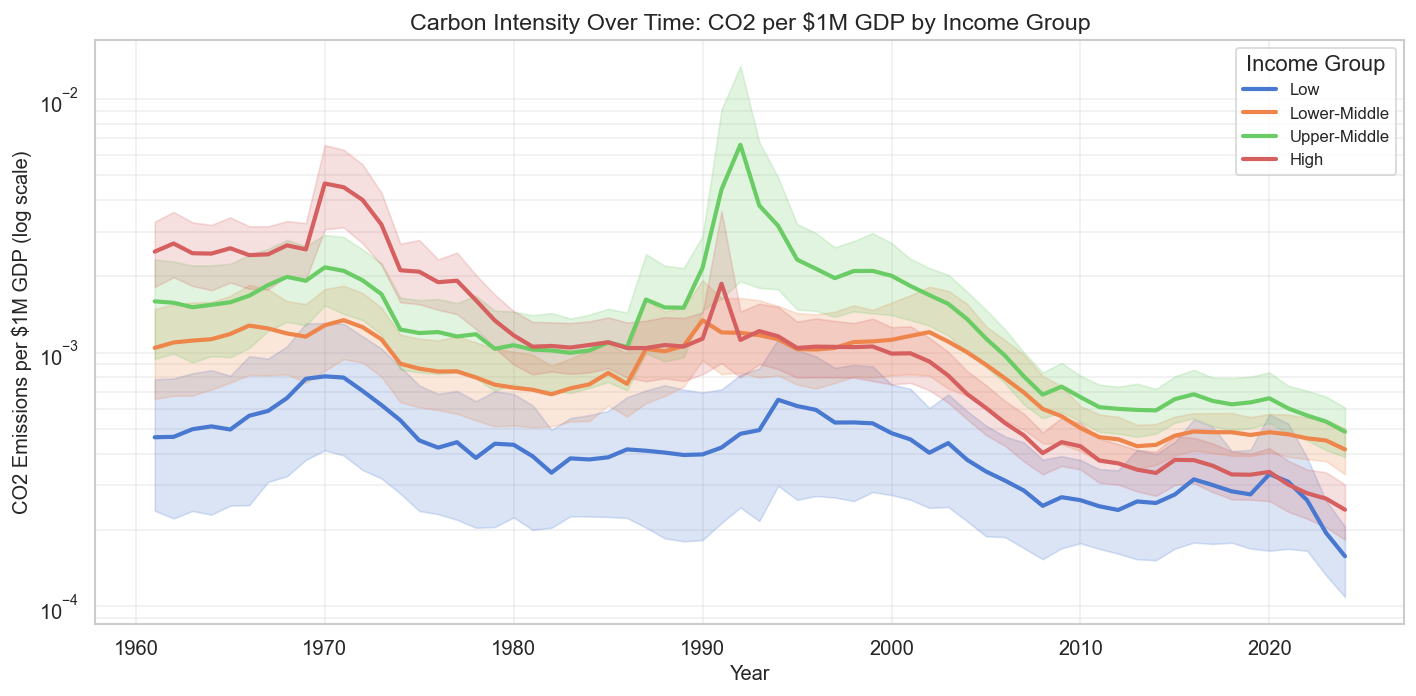

In [15]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=main_df, x='year', y='co2_per_gdp', hue='income_group',
             hue_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'],
             linewidth=2.5)

plt.yscale('log')
plt.title('Carbon Intensity Over Time: CO2 per $1M GDP by Income Group')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions per $1M GDP (log scale)')
plt.legend(title='Income Group')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# filter: year 2024, population > 1M, valid co2_per_gdp
min_pop = 1_000_000

# fail early with a clearer message if a prep cell was skipped
if 'co2_per_gdp' not in base_df.columns:
    raise KeyError("Missing column 'co2_per_gdp'. Re-run the carbon-intensity cell above.")

mask = (base_df['year'] == 2024) & (base_df['population'] > min_pop) & (base_df['co2_per_gdp'] > 0)
df_efficient = base_df[mask].copy()

most_efficient = get_top_bottom_n(df_efficient, 'co2_per_gdp', n=15)
least_efficient = get_top_bottom_n(df_efficient, 'co2_per_gdp', n=15, ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=ax1, x='co2_per_gdp', y='country', data=most_efficient, palette='viridis')
ax1.set_title('Top 15 Most Carbon-Efficient Economies (2024)')
ax1.set_xlabel('CO2 per $1M GDP')
ax1.set_ylabel('')

sns.barplot(ax=ax2, x='co2_per_gdp', y='country', data=least_efficient, palette='magma')
ax2.set_title('Top 15 Least Carbon-Efficient Economies (2024)')
ax2.set_xlabel('CO2 per $1M GDP')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()


# Z-Score outlier visualisation

In [17]:
# Outlier Detection: Carbon Intensity Z-Scores (NumPy)
mask = (main_df['year'] == 2024) & (main_df['population'] > 1_000_000) & (main_df['co2_per_gdp'] > 0)
df_z = main_df.loc[mask, ['country', 'co2_per_gdp']].copy()

# compute z-scores with numpy
values = df_z['co2_per_gdp'].values
mu = np.mean(values)
sigma = np.std(values)
df_z['z_score'] = (values - mu) / sigma

# classify each country by z-score band
df_z['band'] = np.select(
    [np.abs(df_z['z_score'].values) > 3,
     np.abs(df_z['z_score'].values) > 2,
     np.abs(df_z['z_score'].values) > 1],
    ['Extreme (|z|>3)', 'Outlier (|z|>2)', 'Moderate (|z|>1)'],
    default='Normal (|z|≤1)'
)

# sort for plotting
df_z = df_z.sort_values('z_score', ascending=True).reset_index(drop=True)

df_z



,country,co2_per_gdp,z_score,band
0,Switzerland,0.000034,-1.041509,Moderate (|z|>1)
1,Ireland,0.000055,-0.981456,Normal (|z|≤1)
2,Sweden,0.000063,-0.956715,Normal (|z|≤1)
3,Denmark,0.000067,-0.945782,Normal (|z|≤1)
4,Norway,0.000077,-0.916214,Normal (|z|≤1)
...,...,...,...,...
145,Trinidad and Tobago,0.001349,2.820987,Outlier (|z|>2)
146,Laos,0.001479,3.201967,Extreme (|z|>3)
147,Turkmenistan,0.001576,3.489490,Extreme (|z|>3)
148,Iran,0.001668,3.758114,Extreme (|z|>3)


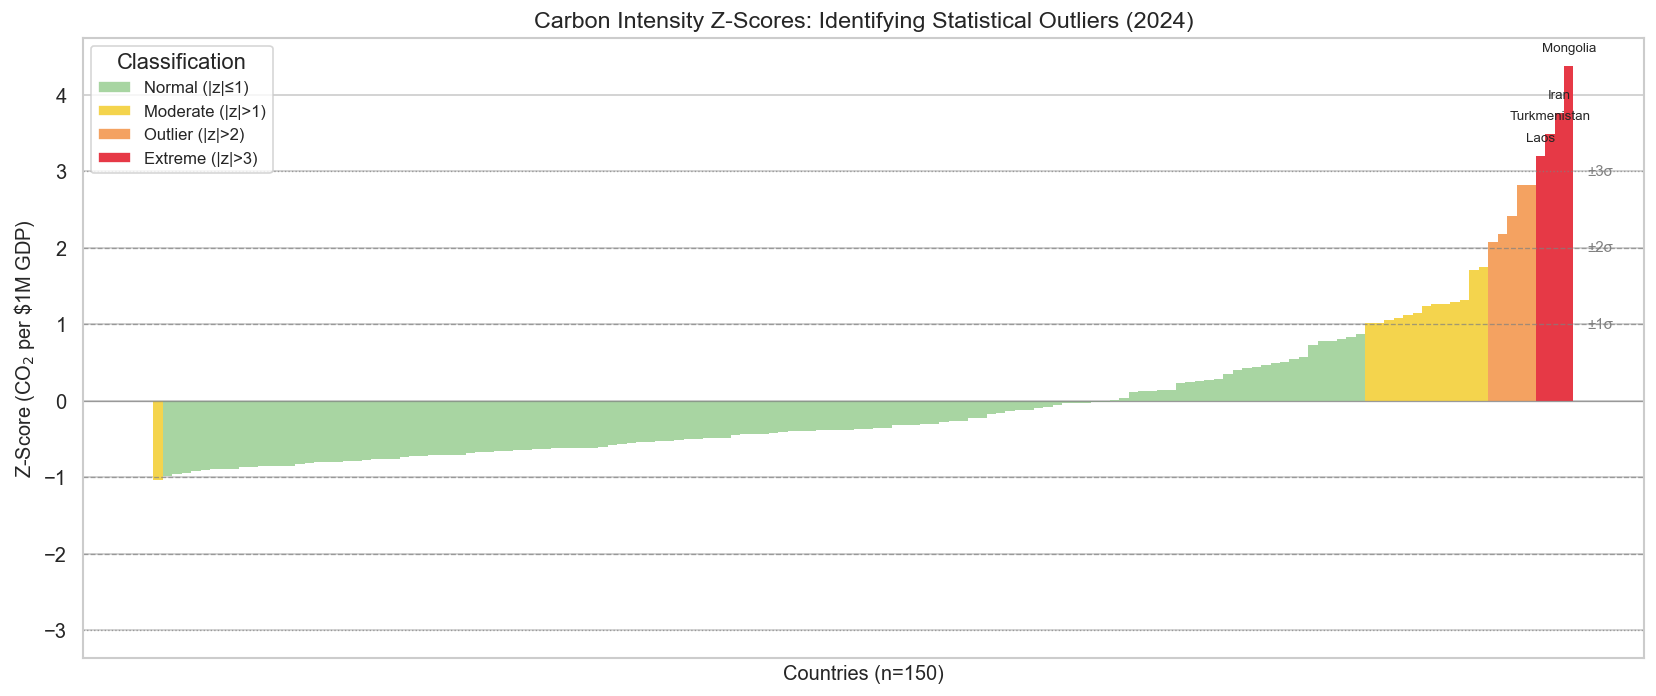

μ = 0.00 | σ = 0.00
Outliers (|z|>2): 9 | Extreme (|z|>3): 4 of 150 countries


In [18]:
# plot
fig, ax = plt.subplots(figsize=(14, 6))

palette = {
    'Normal (|z|≤1)': '#a8d5a2',
    'Moderate (|z|>1)': '#f4d44d',
    'Outlier (|z|>2)': '#f4a261',
    'Extreme (|z|>3)': '#e63946'
}

ax.bar(range(len(df_z)), df_z['z_score'], color=df_z['band'].map(palette), width=1.0, edgecolor='none')

# z-score threshold bands
for z_val, ls, lbl in [(0, '-', 'Mean'), (1, '--', '±1σ'), (2, '--', '±2σ'), (3, ':', '±3σ')]:
    ax.axhline(z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
    if z_val > 0:
        ax.axhline(-z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
        ax.text(len(df_z) + 1, z_val, lbl, va='center', fontsize=9, color='grey')

# label extreme outliers
for _, row in df_z[np.abs(df_z['z_score'].values) > 3].iterrows():
    idx = df_z.index[df_z['country'] == row['country']][0]
    ax.text(idx, row['z_score'] + np.sign(row['z_score']) * 0.15,
            row['country'], ha='center', va='bottom', fontsize=8)

ax.set_title('Carbon Intensity Z-Scores: Identifying Statistical Outliers (2024)')
ax.set_xlabel(f'Countries (n={len(df_z)})')
ax.set_ylabel('Z-Score (CO$_2$ per \\$1M GDP)')
ax.set_xticks([])

# legend
legend_handles = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_handles, loc='upper left', title='Classification')

plt.tight_layout()
plt.show()

# summary statistics
n_outliers = np.sum(np.abs(df_z['z_score'].values) > 2)
n_extreme = np.sum(np.abs(df_z['z_score'].values) > 3)
print(f"μ = {mu:.2f} | σ = {sigma:.2f}")
print(f"Outliers (|z|>2): {n_outliers} | Extreme (|z|>3): {n_extreme} of {len(df_z)} countries")

### Interpreting Carbon Efficiency

**Most efficient economies** (lowest CO2 per $1M GDP):
Countries with service-dominated economies and minimal heavy industry naturally produce less CO2 per unit of economic output. Small island nations and financial centers top this list.

**Least efficient economies** (highest CO2 per $1M GDP):
Countries like Mongolia, Uzbekistan, Turkmenistan, and Kazakhstan are post-Soviet economies that rely heavily on coal for power generation - in some cases up to 90% of their electricity mix. This, combined with relatively low GDP, results in extremely high carbon intensity.

### Biggest Carbon-Intensity Improvers Since 2000

Average trend lines tell us that economies are becoming more efficient overall, but they do not show **where the biggest improvements actually happened**. The slope chart below compares each country's CO2-per-GDP value in **2000** versus the most recent year and highlights the twelve largest absolute declines among countries with populations above 1 million.

Because the values span more than an order of magnitude, the x-axis uses a log scale. Each grey connector line traces one country from its 2000 level (red) to its latest level (green).

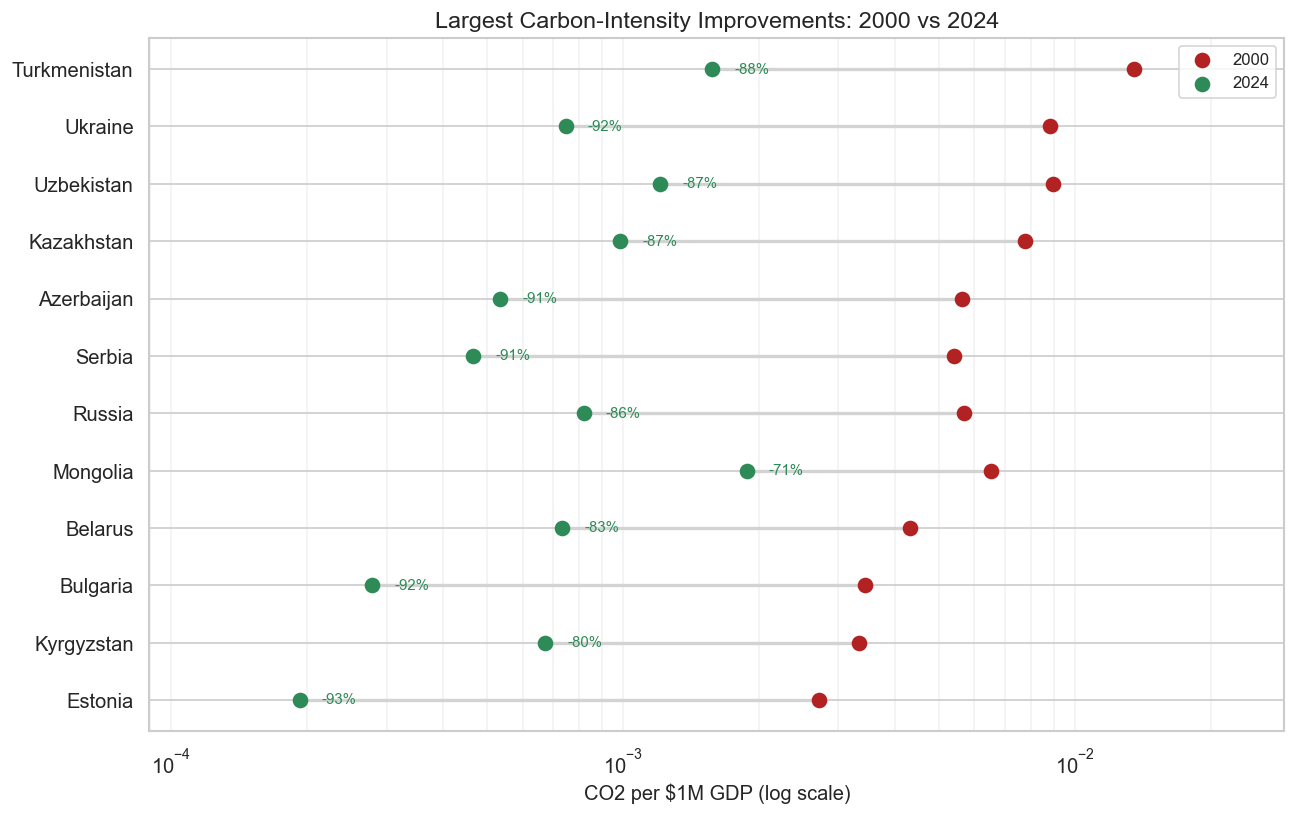

In [19]:
# compare most recent year with the year 2000
comparison_year = 2000
latest_year = int(base_df['year'].max())

# create the comparison dataframe
efficiency_compare = (
    base_df[
        base_df['year'].isin([comparison_year, latest_year])
        & (base_df['population'] > 1_000_000)
        & (base_df['co2_per_gdp'] > 0)
    ][['country', 'iso_code', 'year', 'co2_per_gdp']]
    .dropna()
)

# pivot the table
efficiency_compare = (
    efficiency_compare
    .pivot_table(index=['country', 'iso_code'], columns='year', values='co2_per_gdp', aggfunc='mean')
    .dropna()
)
# calculate the change and pct change
efficiency_compare['change'] = efficiency_compare[latest_year] - efficiency_compare[comparison_year]
efficiency_compare['pct_change'] = (
    efficiency_compare[latest_year] / efficiency_compare[comparison_year] - 1
) * 100

# plot the biggest improvers
plot_improvers = (
    efficiency_compare
    .nsmallest(12, 'change')
    .sort_values('change')
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(plot_improvers))

# iterate through the improvers and plot gray lines between 2000 and most recent
for y, (_, row) in zip(y_pos, plot_improvers.iterrows()):
    ax.plot([row[comparison_year], row[latest_year]], [y, y], color='lightgray', linewidth=2, zorder=1)

# scatter latest year and comparison year
ax.scatter(plot_improvers[comparison_year], y_pos, color='firebrick', s=70, label=str(comparison_year), zorder=2)
ax.scatter(plot_improvers[latest_year], y_pos, color='seagreen', s=70, label=str(latest_year), zorder=3)

# label the improvement percentages
for y, (_, row) in zip(y_pos, plot_improvers.iterrows()):
    ax.text(row[latest_year] * 1.12, y, f"{row['pct_change']:.0f}%", va='center', fontsize=9, color='seagreen')

# visualisation options, scaling and labling
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_improvers['country'])
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlabel('CO2 per $1M GDP (log scale)')
ax.set_title(f'Largest Carbon-Intensity Improvements: {comparison_year} vs {latest_year}')
ax.grid(True, axis='x', which='both', alpha=0.25)
ax.margins(x=0.18)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

### Interpreting the Improvement Gap

The biggest improvers are heavily concentrated in **Eastern Europe and Central Asia**: countries such as **Estonia, Ukraine, Bulgaria, Serbia, Azerbaijan, Kazakhstan, Uzbekistan,** and **Turkmenistan** all show extremely large reductions in CO2 per unit of GDP since 2000.

That regional concentration reinforces an earlier pattern from the notebook: many transition economies experienced a mix of **industrial restructuring, efficiency gains, and GDP growth outpacing emissions growth**. The key takeaway is that decoupling is not only a high-income phenomenon. Some of the most dramatic carbon-intensity improvements came from economies that were reorganising their production base rather than simply getting richer.